ПРОГНОЗ 88 МЛН ОТКРЫТОК НА POSTCROSSING (БАЗОВАЯ МОДЕЛЬ)
С калибровкой по вехам 54–87 млн и детекцией аномалий

1. Загрузка данных...
   Загружено строк: 3077
   Период: с 2019-09-01 23:15:00 по 2026-07-04 19:08:14
   Агрегировано до 1696 дней
   Последняя дата: 2026-07-04

2. Загружено 34 вех (от 54 до 87 млн)
   Медианный интервал между вехами: 73.0 дней (используется для наивного прогноза)

3. Оценка ошибок модели на расширяющихся срезах (шаг 1%)...


23:25:23 - cmdstanpy - INFO - Chain [1] start processing
23:25:23 - cmdstanpy - INFO - Chain [1] done processing
23:25:25 - cmdstanpy - INFO - Chain [1] start processing
23:25:25 - cmdstanpy - INFO - Chain [1] done processing
23:25:26 - cmdstanpy - INFO - Chain [1] start processing
23:25:26 - cmdstanpy - INFO - Chain [1] done processing
23:25:26 - cmdstanpy - INFO - Chain [1] start processing
23:25:27 - cmdstanpy - INFO - Chain [1] done processing
23:25:27 - cmdstanpy - INFO - Chain [1] start processing
23:25:28 - cmdstanpy - INFO - Chain [1] done processing
23:25:28 - cmdstanpy - INFO - Chain [1] start processing
23:25:28 - cmdstanpy - INFO - Chain [1] done processing
23:25:29 - cmdstanpy - INFO - Chain [1] start processing
23:25:29 - cmdstanpy - INFO - Chain [1] done processing
23:25:30 - cmdstanpy - INFO - Chain [1] start processing
23:25:30 - cmdstanpy - INFO - Chain [1] done processing
23:25:31 - cmdstanpy - INFO - Chain [1] start processing
23:25:31 - cmdstanpy - INFO - Chain [1]

   Обработано 73 срезов.

4. Лучший срез по средней абсолютной ошибке (MAE):
   Доля обучения: 90.0%
   MAE: 1.490 дня
   RMSE: 1.500 дня
   MASE: 0.486 ✅ < 1 (лучше наивного)
   Медианная ошибка: -0.179 дня
   Ошибки по отдельным вехам:
      86M: -1.669 дн
      87M: +1.310 дн

5. Построение графиков ошибок для каждой вехи...


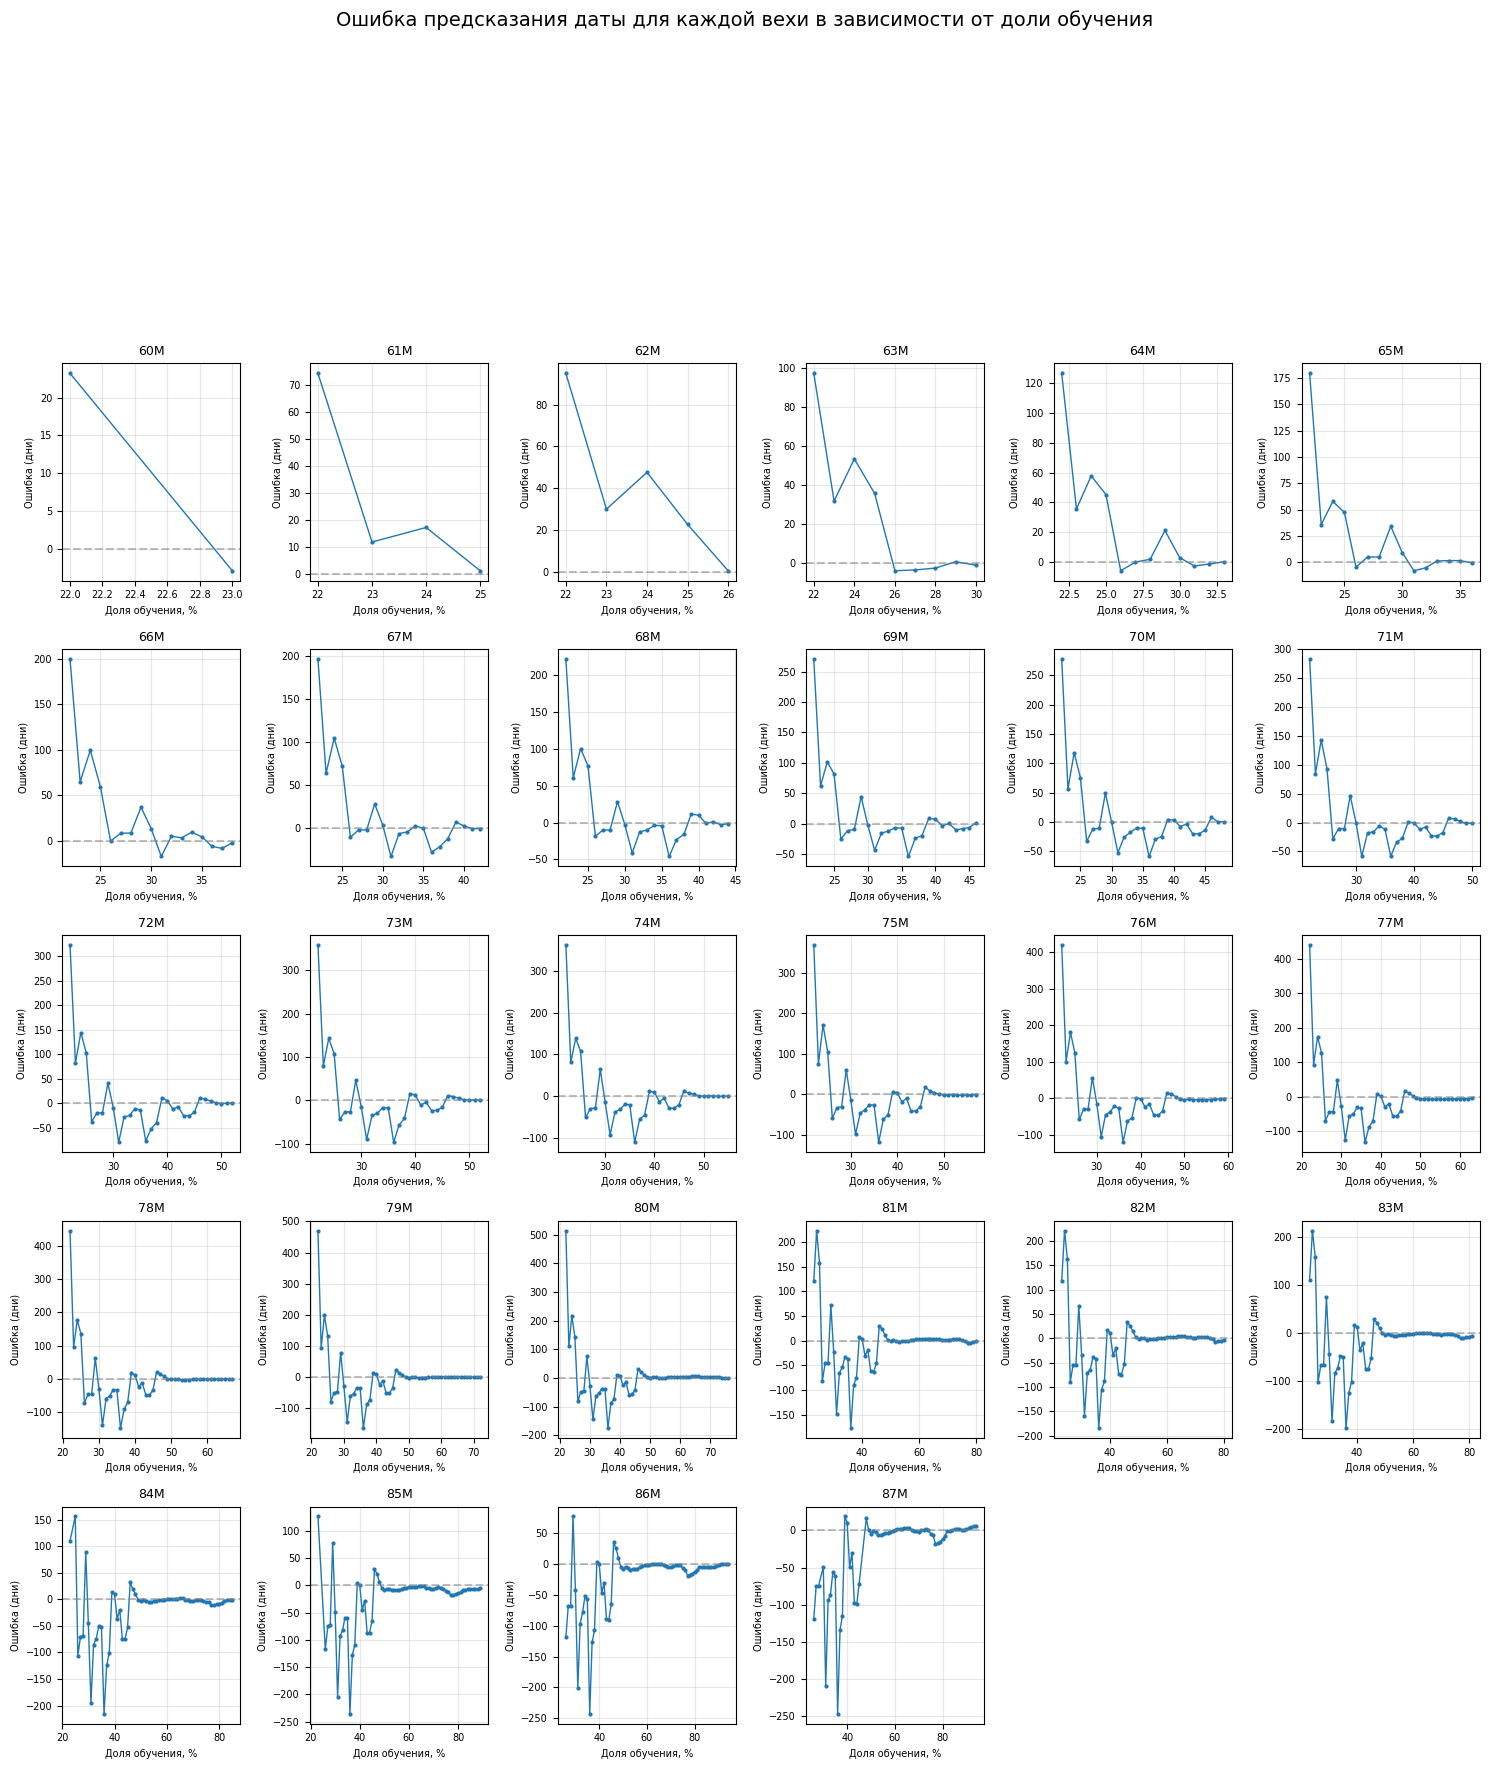

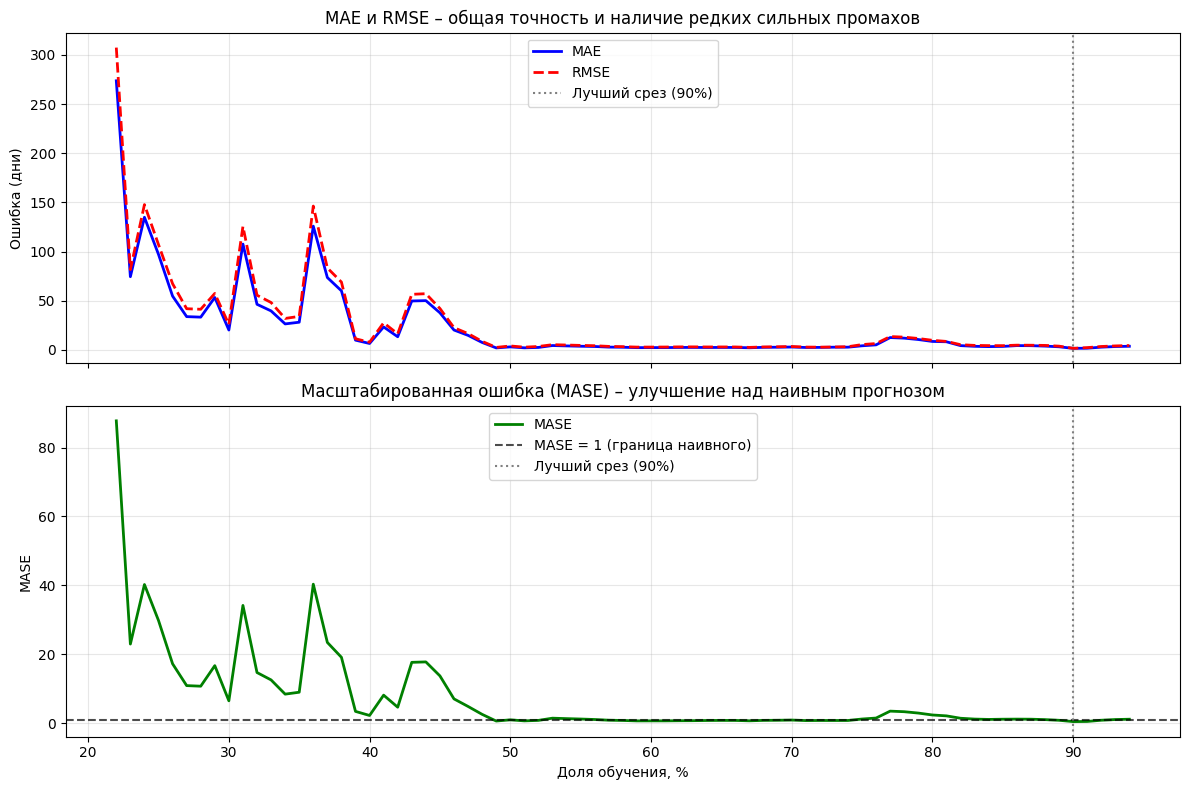


6. Детекция аномалий в ежедневных приростах с учётом пропусков...
   Аномалий (IQR) по нормализованному приросту: 92
   Аномалий (Z-score) по нормализованному приросту: 3

   Анализ аномалий IQR по дням недели и праздникам...
   Всего аномалий IQR: 92
   Распределение по дням недели:
weekday_name
Friday        8
Monday       12
Saturday     12
Sunday        6
Thursday     16
Tuesday      15
Wednesday    23
Name: count, dtype: int64
   Из них праздничных дней: 12

   Первые 10 аномалий с датой и днём недели:
        ds   growth_norm weekday_name  is_holiday
2019-09-02  54981.818182       Monday       False
2019-09-03 144510.171429      Tuesday       False
2019-09-04 102186.224066    Wednesday       False
2019-09-05  64109.387755     Thursday       False
2019-09-06 262894.545455       Friday       False
2019-09-07  63574.054054     Saturday       False
2019-09-09 124902.439024       Monday       False
2019-09-11 164770.331126    Wednesday       False
2019-09-13 109089.326425       Frida

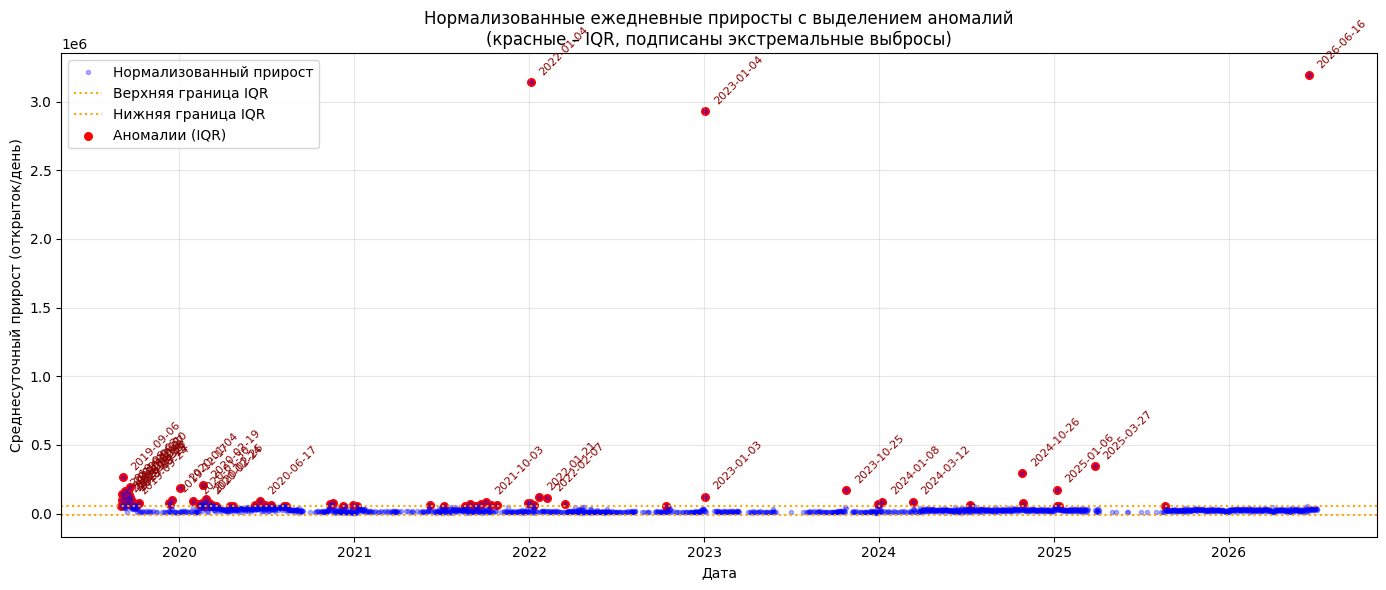

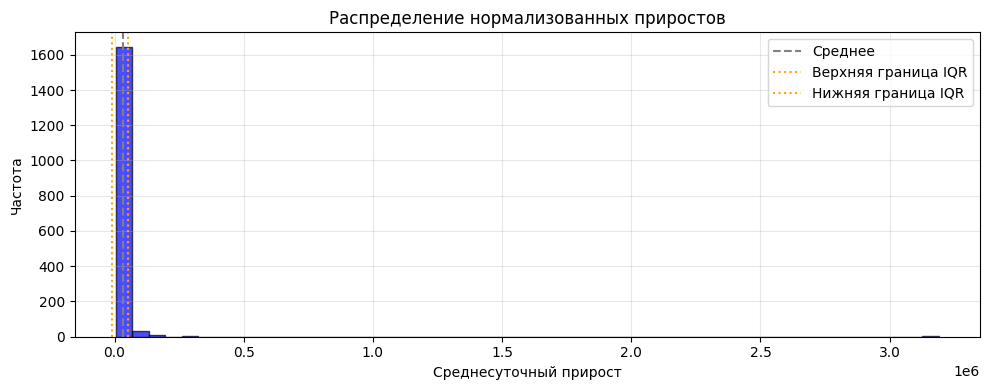

23:27:38 - cmdstanpy - INFO - Chain [1] start processing



7. Прогноз 88 млн с калибровкой...


23:27:40 - cmdstanpy - INFO - Chain [1] done processing


   Исходный прогноз Prophet: 2026-08-29 00:33:58
   Коррекция (медианная ошибка лучшего среза): -0.179 дня
   Скорректированный прогноз: 2026-08-29 04:52:17
   Доверительный интервал (1σ): 2026-08-27 17:07:18 – 2026-08-30 16:37:16


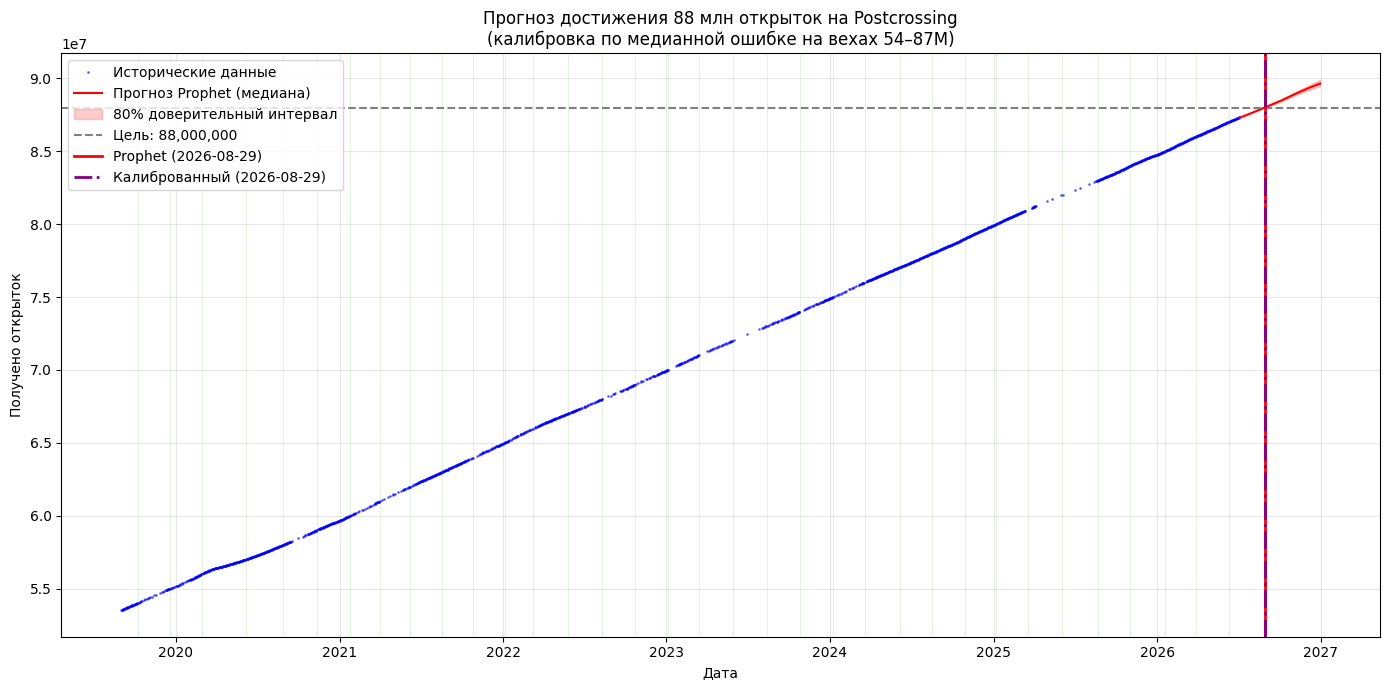

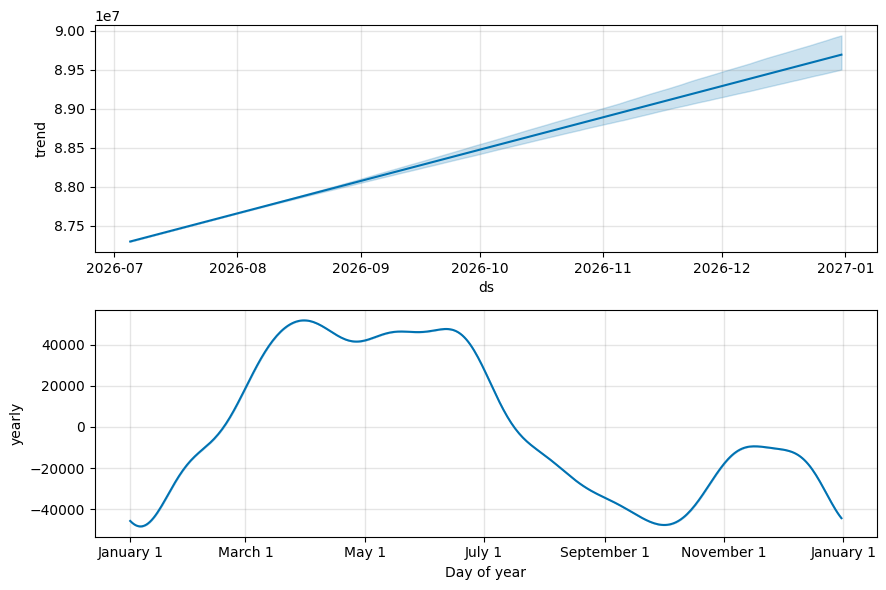


АНАЛИЗ ЗАВЕРШЁН
Финальный прогноз достижения 88 млн: 2026-08-29 04:52:17


In [1]:
# ======================================================================
# ФИНАЛЬНЫЙ НОУТБУК: ПРОГНОЗ ДОСТИЖЕНИЯ 88 МЛН ОТКРЫТОК НА POSTCROSSING
# Базовая модель Prophet (без регрессоров и праздников)
# с калибровкой по историческим вехам (54-87M) и детекцией аномалий
# + расширенная оценка качества: MAE, RMSE, MASE
# + анализ аномалий с учётом дней недели и праздников (только для анализа)
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Установка holidays только для анализа аномалий (не для обучения)
!pip install holidays -q
import holidays

print("="*70)
print("ПРОГНОЗ 88 МЛН ОТКРЫТОК НА POSTCROSSING (БАЗОВАЯ МОДЕЛЬ)")
print("С калибровкой по вехам 54–87 млн и детекцией аномалий")
print("="*70)

# ======================================================================
# 1. ЗАГРУЗКА И АГРЕГАЦИЯ ДАННЫХ
# ======================================================================
print("\n1. Загрузка данных...")
url = "https://huggingface.co/datasets/kamjke/postcrossing-daily-growth/resolve/main/TimeData.csv"
df = pd.read_csv(url, parse_dates=['datetime'])
df = df.sort_values('datetime')
print(f"   Загружено строк: {len(df)}")
print(f"   Период: с {df['datetime'].min()} по {df['datetime'].max()}")

# Агрегация до ежедневных данных (последнее значение за день)
df_daily = df.set_index('datetime').resample('D').last().dropna().reset_index()
df_daily = df_daily.rename(columns={'datetime': 'ds', 'postcards_received': 'y'})[['ds', 'y']]
# Убираем часовой пояс (если он есть) – Prophet требует naive datetime
df_daily['ds'] = df_daily['ds'].dt.tz_localize(None)
print(f"   Агрегировано до {len(df_daily)} дней")
print(f"   Последняя дата: {df_daily['ds'].max().date()}")

# ======================================================================
# 2. ФАКТИЧЕСКИЕ ДАТЫ ДОСТИЖЕНИЯ ВЕХ (54–87 млн) – без таймзоны
# ======================================================================
milestone_dates = {
    54_000_000: '2019-10-07 17:27:00',
    55_000_000: '2019-12-18 16:56:00',
    56_000_000: '2020-02-28 11:49:00',
    57_000_000: '2020-06-05 19:15:00',
    58_000_000: '2020-08-28 09:17:00',
    59_000_000: '2020-11-10 20:51:00',
    60_000_000: '2021-01-24 10:17:00',
    61_000_000: '2021-04-01 00:57:00',
    62_000_000: '2021-06-08 00:01:00',
    63_000_000: '2021-08-18 07:12:00',
    64_000_000: '2021-10-26 13:07:00',
    65_000_000: '2022-01-04 20:39:00',
    66_000_000: '2022-03-09 19:44:00',
    67_000_000: '2022-05-25 13:11:00',
    68_000_000: '2022-08-10 18:13:00',
    69_000_000: '2022-10-22 19:18:00',
    70_000_000: '2023-01-04 23:36:00',
    71_000_000: '2023-03-14 12:32:00',
    72_000_000: '2023-05-28 13:36:00',
    73_000_000: '2023-08-12 19:35:00',
    74_000_000: '2023-10-25 19:35:00',
    75_000_000: '2024-01-08 15:13:00',
    76_000_000: '2024-03-18 20:32:00',
    77_000_000: '2024-06-06 08:58:00',
    78_000_000: '2024-08-16 12:46:00',
    79_000_000: '2024-10-27 20:52:00',
    80_000_000: '2025-01-07 02:32:00',
    81_000_000: '2025-03-18 17:50:00',
    82_000_000: '2025-06-03 02:20:00',
    83_000_000: '2025-08-22 11:36:00',
    84_000_000: '2025-11-02 11:20:00',
    85_000_000: '2026-01-19 01:06:00',
    86_000_000: '2026-03-27 18:27:00',
    87_000_000: '2026-06-09 15:02:00'
}
actual_dates = {k: pd.Timestamp(v) for k, v in milestone_dates.items()}  # naive
thresholds = sorted(actual_dates.keys())
print(f"\n2. Загружено {len(thresholds)} вех (от 54 до 87 млн)")

# Вычисляем медианный интервал между вехами для наивного прогноза (MASE)
sorted_milestones = sorted(actual_dates.items())
intervals = []
for i in range(len(sorted_milestones)-1):
    delta = (sorted_milestones[i+1][1] - sorted_milestones[i][1]).total_seconds() / 86400
    intervals.append(delta)
median_interval = np.median(intervals) if intervals else 365
print(f"   Медианный интервал между вехами: {median_interval:.1f} дней (используется для наивного прогноза)")

# ======================================================================
# 3. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (БЕЗ РЕГРЕССОРОВ И ПРАЗДНИКОВ)
# ======================================================================
def find_cross_date(series, dates, target):
    """Интерполяция даты пересечения целевого значения в прогнозе."""
    for i in range(1, len(series)):
        if series.iloc[i-1] < target <= series.iloc[i]:
            t1 = dates.iloc[i-1].timestamp()
            t2 = dates.iloc[i].timestamp()
            y1 = series.iloc[i-1]
            y2 = series.iloc[i]
            t_cross = t1 + (t2 - t1) * (target - y1) / (y2 - y1)
            return pd.Timestamp.fromtimestamp(t_cross)
    return None

def train_prophet(train_df, **kwargs):
    """Обучает Prophet с заданными параметрами (без доп. регрессоров)."""
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=kwargs.get('changepoint_prior_scale', 0.05),
        seasonality_prior_scale=kwargs.get('seasonality_prior_scale', 10.0),
        interval_width=0.8
    )
    model.fit(train_df[['ds', 'y']])
    return model

def evaluate_errors(train, test, thresholds, actual_dates):
    """Обучает модель на train, прогнозирует test, возвращает ошибки для всех вех."""
    model = train_prophet(train)
    future = pd.DataFrame({'ds': test['ds']})
    forecast = model.predict(future)
    errors = {}
    for t in thresholds:
        if test['y'].max() >= t and t in actual_dates:
            pred_cross = find_cross_date(forecast['yhat'], forecast['ds'], t)
            if pred_cross is not None:
                errors[t] = (pred_cross - actual_dates[t]).total_seconds() / 86400
    return errors

# ======================================================================
# 4. РАСШИРЯЮЩЕЕСЯ ОКНО (ШАГ 1%) – ОЦЕНКА ОШИБОК И МЕТРИК
# ======================================================================
print("\n3. Оценка ошибок модели на расширяющихся срезах (шаг 1%)...")
train_fractions = np.arange(0.05, 0.95, 0.01)
all_slices = []

for frac in train_fractions:
    split_idx = int(len(df_daily) * frac)
    if split_idx < 365:  # минимум 1 год обучения
        continue
    train = df_daily.iloc[:split_idx].copy()
    test = df_daily.iloc[split_idx:].copy()
    if test['y'].max() < min(thresholds):
        continue
    errors = evaluate_errors(train, test, thresholds, actual_dates)
    if not errors:
        continue
    errors_list = list(errors.values())
    mae = np.mean(np.abs(errors_list))
    rmse = np.sqrt(np.mean(np.square(errors_list)))

    # Расчёт MASE на основе наивного прогноза (медианный интервал)
    naive_errors = []
    for t, model_err in errors.items():
        prev_t = max([th for th in thresholds if th < t], default=None)
        if prev_t is not None:
            naive_pred = actual_dates[prev_t] + pd.Timedelta(days=median_interval)
            naive_err = (actual_dates[t] - naive_pred).total_seconds() / 86400
            naive_errors.append(naive_err)
    if naive_errors:
        mae_naive = np.mean(np.abs(naive_errors))
        mase = mae / mae_naive
    else:
        mase = np.nan

    all_slices.append({
        'frac': frac,
        'train_days': len(train),
        'test_days': len(test),
        'mae': mae,
        'rmse': rmse,
        'mase': mase,
        'median_error': np.median(errors_list),
        'std_error': np.std(errors_list),
        'errors': errors
    })

print(f"   Обработано {len(all_slices)} срезов.")

if not all_slices:
    raise ValueError("Нет срезов с ошибками – проверьте пороги.")

# ======================================================================
# 5. ВЫБОР ЛУЧШЕГО СРЕЗА ПО МИНИМАЛЬНОЙ MAE
# ======================================================================
df_slices = pd.DataFrame([
    {k: v for k, v in s.items() if k != 'errors'} for s in all_slices
])
best_idx = df_slices['mae'].idxmin()
best_slice = all_slices[best_idx]
best_frac = best_slice['frac']
best_mae = best_slice['mae']
best_rmse = best_slice['rmse']
best_mase = best_slice['mase']
best_median_err = best_slice['median_error']
best_errors = best_slice['errors']

print("\n4. Лучший срез по средней абсолютной ошибке (MAE):")
print(f"   Доля обучения: {best_frac*100:.1f}%")
print(f"   MAE: {best_mae:.3f} дня")
print(f"   RMSE: {best_rmse:.3f} дня")
print(f"   MASE: {best_mase:.3f} {'✅ < 1 (лучше наивного)' if best_mase < 1 else '⚠️ >= 1 (не лучше наивного)'}")
print(f"   Медианная ошибка: {best_median_err:+.3f} дня")
print("   Ошибки по отдельным вехам:")
for t, err in sorted(best_errors.items()):
    print(f"      {t//1_000_000}M: {err:+.3f} дн")

# ======================================================================
# 6. ГРАФИКИ ДЛЯ КАЖДОЙ ВЕХИ (СЕТКА)
# ======================================================================
print("\n5. Построение графиков ошибок для каждой вехи...")
milestone_list = sorted(actual_dates.keys())
error_by_milestone = {m: [] for m in milestone_list}
frac_list = []
for s in all_slices:
    frac_list.append(s['frac'])
    for m in milestone_list:
        error_by_milestone[m].append(s['errors'].get(m, np.nan))

cols = 6
rows = (len(milestone_list) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))
axes = axes.flatten()

for i, m in enumerate(milestone_list):
    ax = axes[i]
    err_vals = error_by_milestone[m]
    valid = ~np.isnan(err_vals)
    if np.sum(valid) == 0:
        ax.set_visible(False)
        continue
    ax.plot(np.array(frac_list)[valid]*100, np.array(err_vals)[valid], 'o-', markersize=2, linewidth=1)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{m//1_000_000}M', fontsize=9)
    ax.set_xlabel('Доля обучения, %', fontsize=7)
    ax.set_ylabel('Ошибка (дни)', fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Ошибка предсказания даты для каждой вехи в зависимости от доли обучения', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ======================================================================
# 7. ГРАФИКИ: MAE+RMSE и MASE
# ======================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df_slices['frac']*100, df_slices['mae'], 'b-', label='MAE', linewidth=2)
ax1.plot(df_slices['frac']*100, df_slices['rmse'], 'r--', label='RMSE', linewidth=2)
ax1.axvline(x=best_frac*100, color='gray', linestyle=':', label=f'Лучший срез ({best_frac*100:.0f}%)')
ax1.set_ylabel('Ошибка (дни)')
ax1.set_title('MAE и RMSE – общая точность и наличие редких сильных промахов')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df_slices['frac']*100, df_slices['mase'], 'g-', label='MASE', linewidth=2)
ax2.axhline(y=1.0, color='black', linestyle='--', alpha=0.7, label='MASE = 1 (граница наивного)')
ax2.axvline(x=best_frac*100, color='gray', linestyle=':', label=f'Лучший срез ({best_frac*100:.0f}%)')
ax2.set_xlabel('Доля обучения, %')
ax2.set_ylabel('MASE')
ax2.set_title('Масштабированная ошибка (MASE) – улучшение над наивным прогнозом')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ======================================================================
# 8. ДЕТЕКЦИЯ АНОМАЛИЙ С УЧЁТОМ ПРОПУСКОВ И ПРАЗДНИКОВ (только для анализа)
# ======================================================================
print("\n6. Детекция аномалий в ежедневных приростах с учётом пропусков...")

# Вычисляем интервалы между записями для нормализации
df_raw = df.sort_values('datetime').copy()
df_raw['days_since_prev'] = df_raw['datetime'].diff().dt.total_seconds() / 86400
df_raw['days_since_prev'].fillna(1, inplace=True)

# Берём последнюю запись за каждый день (чтобы получить интервал до предыдущего дня)
df_last_per_day = df_raw.groupby(df_raw['datetime'].dt.date).last().reset_index(drop=True)
df_last_per_day['ds'] = pd.to_datetime(df_last_per_day['datetime'].dt.date)
df_last_per_day = df_last_per_day[['ds', 'days_since_prev']]

# Объединяем с агрегированными данными
df_daily_gaps = pd.merge(df_daily, df_last_per_day, on='ds', how='left')
df_daily_gaps['days_since_prev'].fillna(1, inplace=True)

# Нормализованный прирост
df_daily_gaps['growth'] = df_daily_gaps['y'].diff()
df_daily_gaps['growth_norm'] = df_daily_gaps['growth'] / df_daily_gaps['days_since_prev']
df_growth_norm = df_daily_gaps.dropna(subset=['growth_norm']).copy()

# IQR
Q1_n = df_growth_norm['growth_norm'].quantile(0.25)
Q3_n = df_growth_norm['growth_norm'].quantile(0.75)
IQR_n = Q3_n - Q1_n
lower_n = Q1_n - 1.5 * IQR_n
upper_n = Q3_n + 1.5 * IQR_n
anom_iqr = df_growth_norm[(df_growth_norm['growth_norm'] < lower_n) | (df_growth_norm['growth_norm'] > upper_n)]

# Z-score
mean_n = df_growth_norm['growth_norm'].mean()
std_n = df_growth_norm['growth_norm'].std()
df_growth_norm['z_score'] = (df_growth_norm['growth_norm'] - mean_n) / std_n
anom_z = df_growth_norm[df_growth_norm['z_score'].abs() > 3]

print(f"   Аномалий (IQR) по нормализованному приросту: {len(anom_iqr)}")
print(f"   Аномалий (Z-score) по нормализованному приросту: {len(anom_z)}")

# ======================================================================
# 8.1 АНАЛИЗ АНОМАЛИЙ IQR: ДЕНЬ НЕДЕЛИ И ПРАЗДНИКИ
# ======================================================================
print("\n   Анализ аномалий IQR по дням недели и праздникам...")
# Создаём объект с праздниками России (только для анализа)
ru_holidays = holidays.Russia(years=range(2019, 2027))

anom_iqr['weekday'] = anom_iqr['ds'].dt.dayofweek
anom_iqr['weekday_name'] = anom_iqr['ds'].dt.day_name()
anom_iqr['is_holiday'] = anom_iqr['ds'].dt.date.apply(lambda d: d in ru_holidays)

print(f"   Всего аномалий IQR: {len(anom_iqr)}")
print("   Распределение по дням недели:")
print(anom_iqr['weekday_name'].value_counts().sort_index())
print(f"   Из них праздничных дней: {anom_iqr['is_holiday'].sum()}")
print("\n   Первые 10 аномалий с датой и днём недели:")
print(anom_iqr[['ds', 'growth_norm', 'weekday_name', 'is_holiday']].head(10).to_string(index=False))

# ======================================================================
# 8.2 ВЫВОД АНОМАЛИЙ ПО Z-SCORE С ТОЧНЫМ ВРЕМЕНЕМ
# ======================================================================
print("\n   === АНОМАЛИИ ПО Z-SCORE (|z| > 3) С ТОЧНЫМ ВРЕМЕНЕМ ===")
if not anom_z.empty:
    df_time = df.groupby(df['datetime'].dt.date).agg(time=('datetime', 'min')).reset_index()
    df_time.columns = ['ds', 'time']
    df_time['ds'] = pd.to_datetime(df_time['ds'])

    anom_z_with_time = pd.merge(anom_z, df_time, on='ds', how='left')
    for _, row in anom_z_with_time.iterrows():
        print(f"   {row['ds'].date()} {row['time'].strftime('%H:%M:%S')}  |  "
              f"z-score = {row['z_score']:.2f}  |  "
              f"growth_norm = {row['growth_norm']:.0f} откр./день")
else:
    print("   Нет аномалий с |z| > 3")

# ======================================================================
# 8.3 ГРАФИК НОРМАЛИЗОВАННЫХ ПРИРОСТОВ С ПОДПИСЯМИ АНОМАЛИЙ
# ======================================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_growth_norm['ds'], df_growth_norm['growth_norm'], 'b.', alpha=0.3, label='Нормализованный прирост')
ax.axhline(y=upper_n, color='orange', linestyle=':', label='Верхняя граница IQR')
ax.axhline(y=lower_n, color='orange', linestyle=':', label='Нижняя граница IQR')
ax.scatter(anom_iqr['ds'], anom_iqr['growth_norm'], color='red', s=30, label='Аномалии (IQR)')

# Подписываем самые сильные аномалии (выходящие за 2*IQR от границы)
extreme = anom_iqr[
    (anom_iqr['growth_norm'] > upper_n + 2*IQR_n) |
    (anom_iqr['growth_norm'] < lower_n - 2*IQR_n)
]
for _, row in extreme.iterrows():
    ax.annotate(row['ds'].strftime('%Y-%m-%d'),
                xy=(row['ds'], row['growth_norm']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color='darkred', rotation=45)

ax.set_xlabel('Дата')
ax.set_ylabel('Среднесуточный прирост (открыток/день)')
ax.set_title('Нормализованные ежедневные приросты с выделением аномалий\n(красные – IQR, подписаны экстремальные выбросы)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Гистограмма распределения
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_growth_norm['growth_norm'], bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.axvline(x=mean_n, color='gray', linestyle='--', label='Среднее')
ax.axvline(x=upper_n, color='orange', linestyle=':', label='Верхняя граница IQR')
ax.axvline(x=lower_n, color='orange', linestyle=':', label='Нижняя граница IQR')
ax.set_xlabel('Среднесуточный прирост')
ax.set_ylabel('Частота')
ax.set_title('Распределение нормализованных приростов')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ======================================================================
# 9. ПРОГНОЗ 88M С КАЛИБРОВКОЙ ПО МЕДИАННОЙ ОШИБКЕ ЛУЧШЕГО СРЕЗА
# ======================================================================
print("\n7. Прогноз 88 млн с калибровкой...")
target_88 = 88_000_000

# Обучаем базовую модель на всех данных
model_full = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    interval_width=0.8
)
model_full.fit(df_daily[['ds', 'y']])

# Прогноз на 180 дней
future_full = model_full.make_future_dataframe(periods=180, include_history=False)
forecast_full = model_full.predict(future_full)

pred_88_raw = find_cross_date(forecast_full['yhat'], forecast_full['ds'], target_88)
if pred_88_raw is None:
    raise ValueError("Прогноз не достигает 88M – увеличьте periods.")

print(f"   Исходный прогноз Prophet: {pred_88_raw.strftime('%Y-%m-%d %H:%M:%S')}")
calibrated_88 = pred_88_raw - pd.Timedelta(days=best_median_err)
print(f"   Коррекция (медианная ошибка лучшего среза): {best_median_err:+.3f} дня")
print(f"   Скорректированный прогноз: {calibrated_88.strftime('%Y-%m-%d %H:%M:%S')}")

std_err = best_slice['std_error']
lower_88 = calibrated_88 - pd.Timedelta(days=std_err)
upper_88 = calibrated_88 + pd.Timedelta(days=std_err)
print(f"   Доверительный интервал (1σ): {lower_88.strftime('%Y-%m-%d %H:%M:%S')} – {upper_88.strftime('%Y-%m-%d %H:%M:%S')}")

# ======================================================================
# 10. ФИНАЛЬНЫЙ ГРАФИК ПРОГНОЗА
# ======================================================================
plt.figure(figsize=(14, 7))
plt.plot(df_daily['ds'], df_daily['y'], 'b.', markersize=2, alpha=0.5, label='Исторические данные')
plt.plot(forecast_full['ds'], forecast_full['yhat'], 'r-', label='Прогноз Prophet (медиана)')
plt.fill_between(forecast_full['ds'], forecast_full['yhat_lower'], forecast_full['yhat_upper'],
                 color='red', alpha=0.2, label='80% доверительный интервал')
plt.axhline(y=target_88, color='gray', linestyle='--', label='Цель: 88,000,000')
plt.axvline(x=pred_88_raw, color='red', linestyle='-', linewidth=2,
            label=f'Prophet ({pred_88_raw.strftime("%Y-%m-%d")})')
plt.axvline(x=calibrated_88, color='purple', linestyle='-.', linewidth=2,
            label=f'Калиброванный ({calibrated_88.strftime("%Y-%m-%d")})')
for t, dt in actual_dates.items():
    plt.axvline(x=dt, color='green', alpha=0.15, linewidth=0.5)

plt.xlabel('Дата')
plt.ylabel('Получено открыток')
plt.title('Прогноз достижения 88 млн открыток на Postcrossing\n(калибровка по медианной ошибке на вехах 54–87M)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Компоненты сезонности
fig2 = model_full.plot_components(forecast_full)
plt.show()

print("\n" + "="*70)
print("АНАЛИЗ ЗАВЕРШЁН")
print(f"Финальный прогноз достижения 88 млн: {calibrated_88.strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)